<a href="https://colab.research.google.com/github/vaghelazeel/HNSCC-MultiOmics-Analysis/blob/main/HNSCC_MultiOmics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.9 MB/s eta 0:00:00
All libraries loaded successfully
Mounted at /content/drive
Found: TCGA-HNSC.gene_expression.tsv.gz.gz
Found: TCGA-HNSC.clinical.tsv.gz
Found: TCGA-HNSC.survival.tsv.gz
Expression shape: (20530, 567)
Clinical shape: (604, 93)
Survival shape: (603, 4)
Expression first 3 columns: ['sample', 'TCGA-CR-7383-01', 'TCGA-CR-7398-01']
Survival columns: ['sample', 'OS.time', 'OS', '_PATIENT']
First 10 gene IDs:
['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1', 'REM1', 'MTVR2', 'RTN4RL2']
Clinical sample column: sample
Survival sample column: sample
Common samples: 520
Expression filtered: (20530, 566)
Clinical filtered: (596, 93)
Survival filtered: (596, 4)
Patient x gene matrix: (565, 20530)
Top 5 highest variance genes:
gene
MYH2         28.692515
MYH1         23.125386
MYL1  

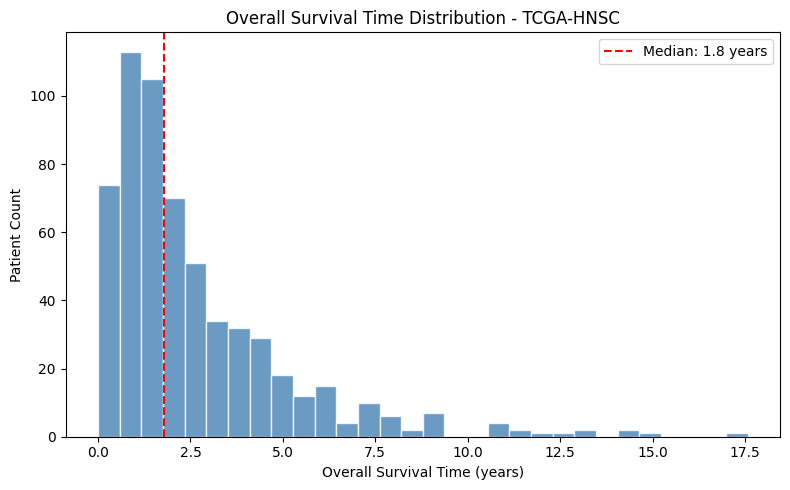

Saved fig1_survival_distribution.png


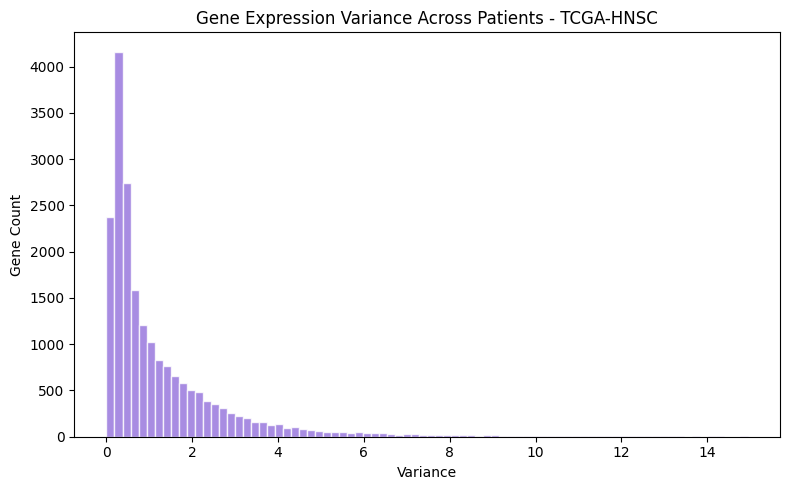

Genes with variance above 1: 8036
Saved fig2_expression_variance.png


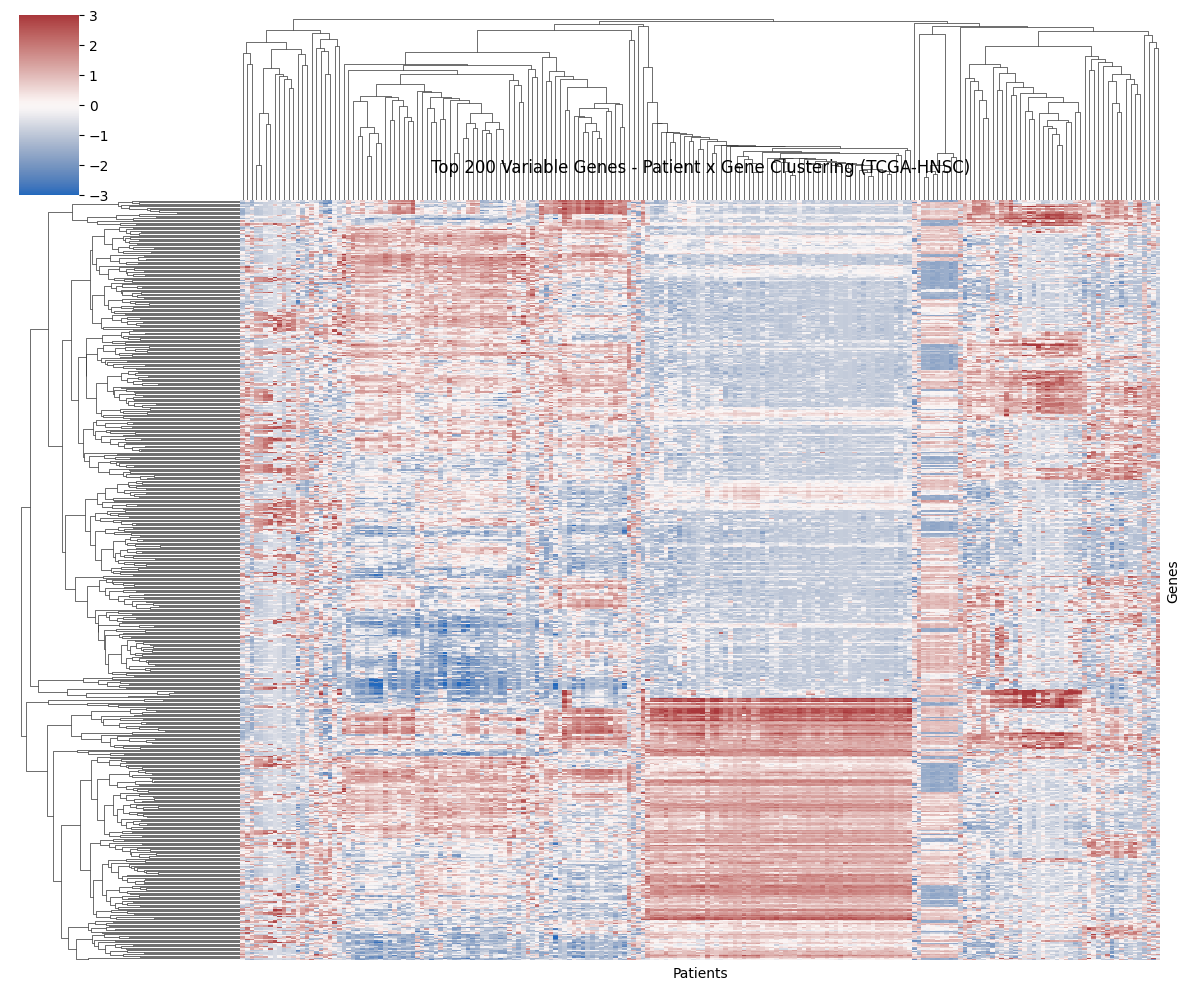

Saved fig3_clustermap.png
CD44 matches: ['CD44']
CD24 matches: ['CD244', 'CD247', 'CD248', 'CD24']
Biomarker table shape: (565, 4)
       CD44_val  CD24_val
count   565.000   565.000
mean     14.304     4.318
std       0.799     1.358
min       8.910     0.000
25%      13.888     3.424
50%      14.386     4.312
75%      14.794     5.237
max      17.097     8.523


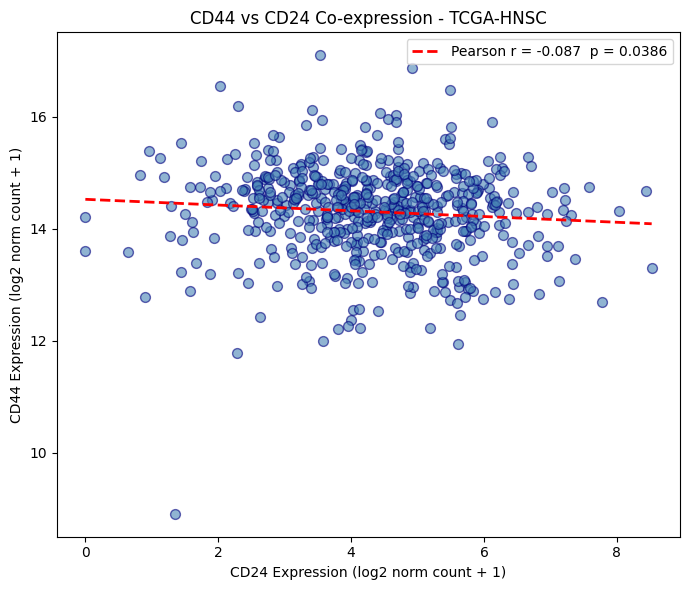

Pearson r = -0.087   p = 0.0386
Saved fig4_cd44_cd24_scatter.png
Subgroup counts:
subgroup
Others                409
CD44_high_CD24_low    156
Name: count, dtype: int64
Merged dataset shape: (686, 6)
CD44-high/CD24-low group: 191
Others group: 495
Log-rank p-value: 0.0901


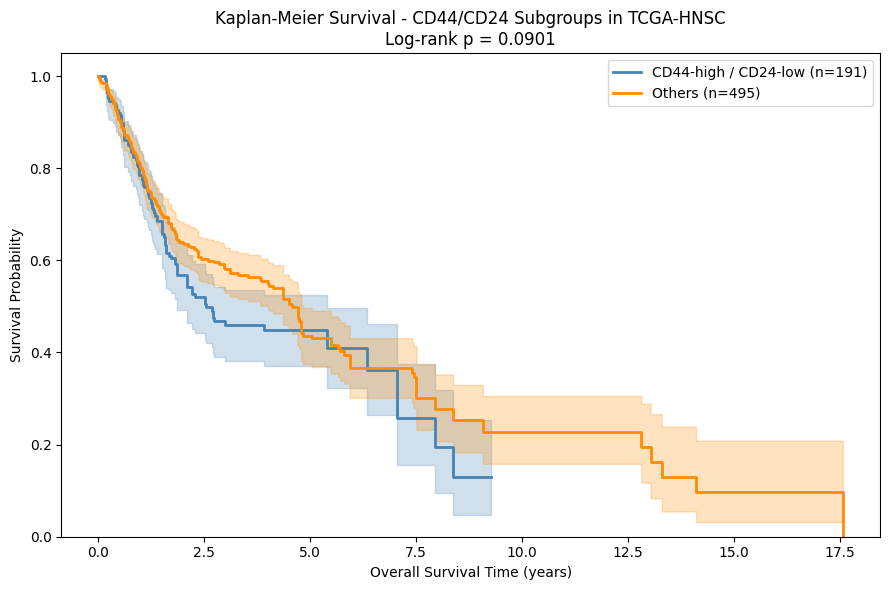

Saved fig5_kaplanmeier.png
Figure save status:
  Saved: fig1_survival_distribution.png
  Saved: fig2_expression_variance.png
  Saved: fig3_clustermap.png
  Saved: fig4_cd44_cd24_scatter.png
  Saved: fig5_kaplanmeier.png

Download all figures from the Files panel on the left side of Colab.
Right click each file and click Download.


In [ ]:
# HNSCC Multi-Omics Analysis
# Author: Zeel Vaghela, MSc Bioinformatics, Teesside University, UK
# Dataset: TCGA-HNSC via UCSC Xena


# CELL 1 - Install libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn lifelines scipy


# CELL 2 - Import libraries
import os
import gzip
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy import stats

print("All libraries loaded successfully")


# CELL 3 - Mount Google Drive (needed for clinical and survival files)
from google.colab import drive
drive.mount('/content/drive')


# CELL 4 - Set file paths and check all three files exist
FP_EXPR = "/content/TCGA-HNSC.gene_expression.tsv.gz.gz"
FP_CLIN = "/content/drive/MyDrive/Colab Notebooks/TCGA-HNSC.clinical.tsv.gz"
FP_SURV = "/content/drive/MyDrive/Colab Notebooks/TCGA-HNSC.survival.tsv.gz"
SAVE_DIR = "/content"

for p in [FP_EXPR, FP_CLIN, FP_SURV]:
    if os.path.exists(p):
        print("Found:", os.path.basename(p))
    else:
        print("MISSING:", os.path.basename(p))


# CELL 5 - Load all three files
def load_file(path):
    try:
        with gzip.open(path, 'rt') as f:
            return pd.read_csv(f, sep='\t', low_memory=False)
    except Exception:
        return pd.read_csv(path, sep='\t', low_memory=False)

expr_df = load_file(FP_EXPR)
clin_df = load_file(FP_CLIN)
surv_df = load_file(FP_SURV)

print("Expression shape:", expr_df.shape)
print("Clinical shape:", clin_df.shape)
print("Survival shape:", surv_df.shape)
print("Expression first 3 columns:", expr_df.columns[:3].tolist())
print("Survival columns:", surv_df.columns.tolist())


# CELL 6 - Check gene ID format
print("First 10 gene IDs:")
print(expr_df.iloc[:10, 0].tolist())


# CELL 7 - Clean and align sample IDs
clin_df.columns = clin_df.columns.str.strip()
surv_df.columns = surv_df.columns.str.strip()

sample_col_clin = None
for c in clin_df.columns:
    if "submitter" in c.lower() or "sample" in c.lower():
        sample_col_clin = c
        break

sample_col_surv = None
for c in surv_df.columns:
    if "submitter" in c.lower() or "sample" in c.lower():
        sample_col_surv = c
        break

print("Clinical sample column:", sample_col_clin)
print("Survival sample column:", sample_col_surv)

clin_df["sample"] = clin_df[sample_col_clin].str.slice(0, 12)
surv_df["sample"] = surv_df[sample_col_surv].str.slice(0, 12)

gene_col_name = expr_df.columns[0]
expr_df = expr_df.rename(columns={gene_col_name: "gene"})

old_cols = list(expr_df.columns)
new_cols = ["gene"] + [c[:12] for c in old_cols[1:]]
expr_df.columns = new_cols

common = set(expr_df.columns[1:]) & set(clin_df["sample"]) & set(surv_df["sample"])
print("Common samples:", len(common))

expr_filt = expr_df[["gene"] + list(common)].copy()
clin_df = clin_df[clin_df["sample"].isin(common)].reset_index(drop=True)
surv_df = surv_df[surv_df["sample"].isin(common)].reset_index(drop=True)

print("Expression filtered:", expr_filt.shape)
print("Clinical filtered:", clin_df.shape)
print("Survival filtered:", surv_df.shape)


# CELL 8 - Build patient x gene matrix
expr_num = expr_filt.set_index("gene").T.copy()
expr_num.index.name = "sample"

print("Patient x gene matrix:", expr_num.shape)

gene_var = expr_num.var(axis=0)
print("Top 5 highest variance genes:")
print(gene_var.nlargest(5))


# CELL 9 - Figure 1: Overall Survival Time Distribution
surv_df["OS_years"] = surv_df["OS.time"] / 365.25

print("Survival statistics:")
print(surv_df[["OS.time", "OS_years", "OS"]].describe().round(2))

plt.figure(figsize=(8, 5))
plt.hist(surv_df["OS_years"], bins=30, color="steelblue", alpha=0.8, edgecolor="white")
med = round(surv_df["OS_years"].median(), 2)
plt.axvline(surv_df["OS_years"].median(), color="red", linestyle="--", linewidth=1.5,
            label="Median: " + str(med) + " years")
plt.title("Overall Survival Time Distribution - TCGA-HNSC")
plt.xlabel("Overall Survival Time (years)")
plt.ylabel("Patient Count")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig1_survival_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig1_survival_distribution.png")


# CELL 10 - Figure 2: Gene Expression Variance
plt.figure(figsize=(8, 5))
plt.hist(gene_var[gene_var < 15], bins=80, color="mediumpurple", alpha=0.8, edgecolor="white")
plt.title("Gene Expression Variance Across Patients - TCGA-HNSC")
plt.xlabel("Variance")
plt.ylabel("Gene Count")
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig2_expression_variance.png", dpi=200, bbox_inches="tight")
plt.show()
print("Genes with variance above 1:", (gene_var > 1).sum())
print("Saved fig2_expression_variance.png")


# CELL 11 - Figure 3: Hierarchical Clustering Heatmap
# This cell takes 2 to 3 minutes, do not interrupt it

scaler = StandardScaler()
expr_z = pd.DataFrame(
    scaler.fit_transform(expr_num),
    index=expr_num.index,
    columns=expr_num.columns
)

top_genes = gene_var.nlargest(200).index.tolist()

cg = sns.clustermap(
    expr_z[top_genes],
    metric="euclidean",
    method="average",
    cmap="vlag",
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=False,
    vmin=-3,
    vmax=3
)
cg.ax_heatmap.set_title("Top 200 Variable Genes - Patient x Gene Clustering (TCGA-HNSC)", pad=20)
cg.ax_heatmap.set_xlabel("Patients")
cg.ax_heatmap.set_ylabel("Genes")
cg.savefig(SAVE_DIR + "/fig3_clustermap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig3_clustermap.png")


# CELL 12 - Search for CD44 and CD24
cd44_row = expr_filt[expr_filt["gene"].str.contains("CD44", na=False)]
cd24_row = expr_filt[expr_filt["gene"].str.contains("CD24", na=False)]

print("CD44 matches:", cd44_row["gene"].tolist())
print("CD24 matches:", cd24_row["gene"].tolist())


# CELL 13 - Extract CD44 and CD24 values
cd44_series = cd44_row.iloc[0].drop("gene").rename("CD44")
cd24_series = cd24_row.iloc[0].drop("gene").rename("CD24")

biomarkers = pd.concat([cd44_series, cd24_series], axis=1)
biomarkers.index.name = "sample"

biomarkers["CD44_val"] = pd.to_numeric(biomarkers["CD44"], errors="coerce")
biomarkers["CD24_val"] = pd.to_numeric(biomarkers["CD24"], errors="coerce")
biomarkers = biomarkers.dropna(subset=["CD44_val", "CD24_val"])

print("Biomarker table shape:", biomarkers.shape)
print(biomarkers[["CD44_val", "CD24_val"]].describe().round(3))


# CELL 14 - Figure 4: CD44 vs CD24 Scatter Plot
r, p_corr = stats.pearsonr(biomarkers["CD44_val"], biomarkers["CD24_val"])

m, b = np.polyfit(biomarkers["CD24_val"], biomarkers["CD44_val"], 1)
x_line = np.linspace(biomarkers["CD24_val"].min(), biomarkers["CD24_val"].max(), 200)

plt.figure(figsize=(7, 6))
plt.scatter(biomarkers["CD24_val"], biomarkers["CD44_val"],
            s=50, color="steelblue", edgecolors="navy", alpha=0.6)
plt.plot(x_line, m * x_line + b, color="red", linewidth=2, linestyle="--",
         label="Pearson r = " + str(round(r, 3)) + "  p = " + str(round(p_corr, 4)))
plt.title("CD44 vs CD24 Co-expression - TCGA-HNSC")
plt.xlabel("CD24 Expression (log2 norm count + 1)")
plt.ylabel("CD44 Expression (log2 norm count + 1)")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig4_cd44_cd24_scatter.png", dpi=200, bbox_inches="tight")
plt.show()
print("Pearson r =", round(r, 3), "  p =", round(p_corr, 4))
print("Saved fig4_cd44_cd24_scatter.png")


# CELL 15 - Define subgroups
cd44_med = biomarkers["CD44_val"].median()
cd24_med = biomarkers["CD24_val"].median()

biomarkers["subgroup"] = "Others"
biomarkers.loc[
    (biomarkers["CD44_val"] > cd44_med) & (biomarkers["CD24_val"] < cd24_med),
    "subgroup"
] = "CD44_high_CD24_low"

print("Subgroup counts:")
print(biomarkers["subgroup"].value_counts())


# CELL 16 - Merge with survival data
merged = pd.merge(
    surv_df,
    biomarkers.reset_index()[["sample", "subgroup"]],
    on="sample",
    how="inner"
)
print("Merged dataset shape:", merged.shape)

grp_stem = merged[merged["subgroup"] == "CD44_high_CD24_low"]
grp_other = merged[merged["subgroup"] == "Others"]

print("CD44-high/CD24-low group:", len(grp_stem))
print("Others group:", len(grp_other))

result = logrank_test(
    grp_stem["OS.time"],
    grp_other["OS.time"],
    event_observed_A=grp_stem["OS"],
    event_observed_B=grp_other["OS"]
)
print("Log-rank p-value:", round(result.p_value, 4))


# CELL 17 - Figure 5: Kaplan-Meier Survival Curves
kmf1 = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(9, 6))

kmf1.fit(
    grp_stem["OS.time"] / 365.25,
    event_observed=grp_stem["OS"],
    label="CD44-high / CD24-low (n=" + str(len(grp_stem)) + ")"
)
kmf1.plot_survival_function(ax=ax, ci_show=True, color="steelblue", linewidth=2)

kmf2.fit(
    grp_other["OS.time"] / 365.25,
    event_observed=grp_other["OS"],
    label="Others (n=" + str(len(grp_other)) + ")"
)
kmf2.plot_survival_function(ax=ax, ci_show=True, color="darkorange", linewidth=2)

ax.set_title("Kaplan-Meier Survival - CD44/CD24 Subgroups in TCGA-HNSC\nLog-rank p = " + str(round(result.p_value, 4)))
ax.set_xlabel("Overall Survival Time (years)")
ax.set_ylabel("Survival Probability")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig5_kaplanmeier.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig5_kaplanmeier.png")


# CELL 18 - Confirm all figures saved
figures = [
    "fig1_survival_distribution.png",
    "fig2_expression_variance.png",
    "fig3_clustermap.png",
    "fig4_cd44_cd24_scatter.png",
    "fig5_kaplanmeier.png"
]

print("Figure save status:")
for f in figures:
    path = SAVE_DIR + "/" + f
    if os.path.exists(path):
        print("  Saved:", f)
    else:
        print("  MISSING:", f)

